In [1]:
print("Credit Card Fraud Detection with Azure ML")
print()
print("Team Members:")
print("  Jyotheswar Narayana Narravula")
print("  Mohith Reddy Kovvuri")
print("  Vaishnavi Madduri")
print()
print("Wright State University")

Credit Card Fraud Detection with Azure ML

Team Members:
  Jyotheswar Narayana Narravula
  Mohith Reddy Kovvuri
  Vaishnavi Madduri

Wright State University


In [23]:
# importing libraries i need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("libraries imported successfully")

libraries imported successfully


In [24]:
# loading the dataset
df = pd.read_csv('./data/creditcard.csv')
print("dataset loaded!")
print("total rows:", df.shape[0])
print("total columns:", df.shape[1])
df.head()

dataset loaded!
total rows: 284807
total columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


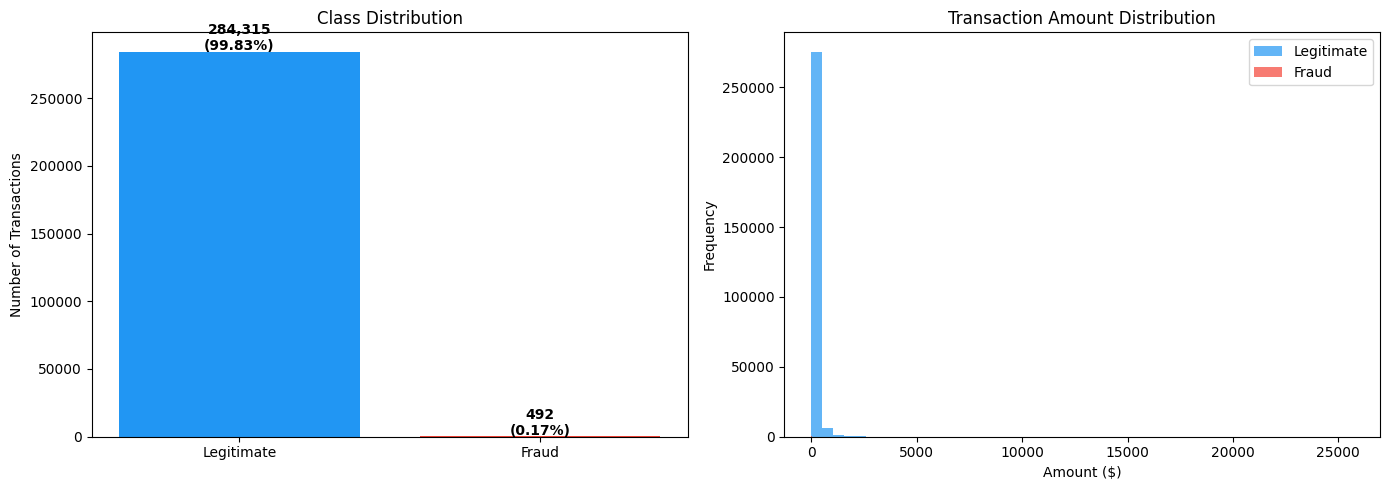

charts saved!


In [26]:
# plotting the class imbalance
import os
os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# class distribution
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color=['#2196F3', '#F44336'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.2f}%)',
                ha='center', fontweight='bold')

# amount distribution
axes[1].hist(df[df['Class']==0]['Amount'], bins=50,
             color='#2196F3', alpha=0.7, label='Legitimate')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50,
             color='#F44336', alpha=0.7, label='Fraud')
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('./outputs/class_distribution.png', dpi=150)
plt.show()
print("charts saved!")

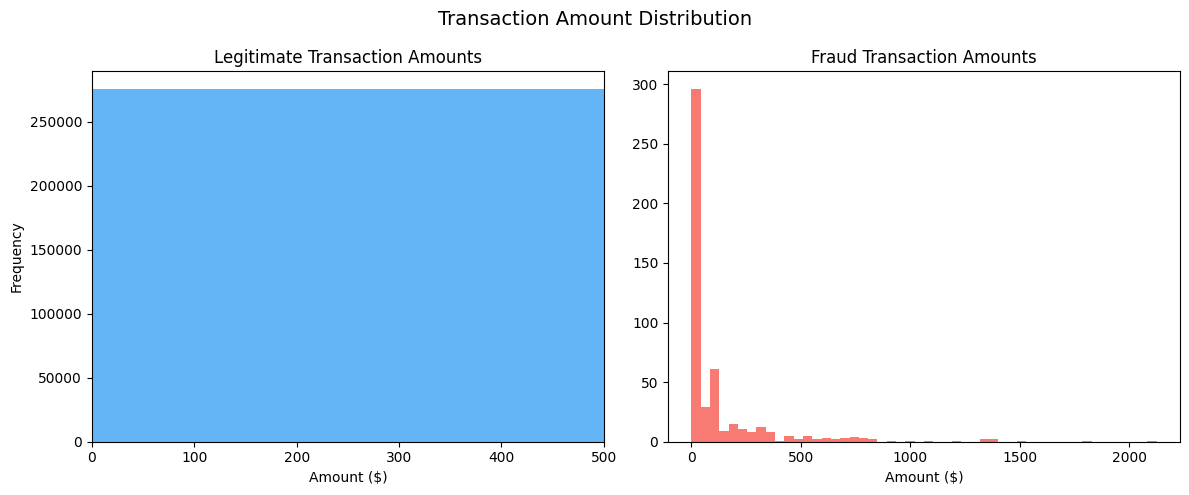

average legitimate transaction: $ 88.29
average fraud transaction: $ 122.21


In [46]:
# looking at transaction amounts
# wanted to see if fraud transactions have different amounts

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df[df['Class'] == 0]['Amount'],
             bins=50, color='#2196F3', alpha=0.7)
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim([0, 500])

axes[1].hist(df[df['Class'] == 1]['Amount'],
             bins=50, color='#F44336', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount ($)')

plt.suptitle('Transaction Amount Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('./outputs/amount_distribution.png', dpi=150)
plt.show()

print("average legitimate transaction: $", round(df[df['Class']==0]['Amount'].mean(), 2))
print("average fraud transaction: $", round(df[df['Class']==1]['Amount'].mean(), 2))


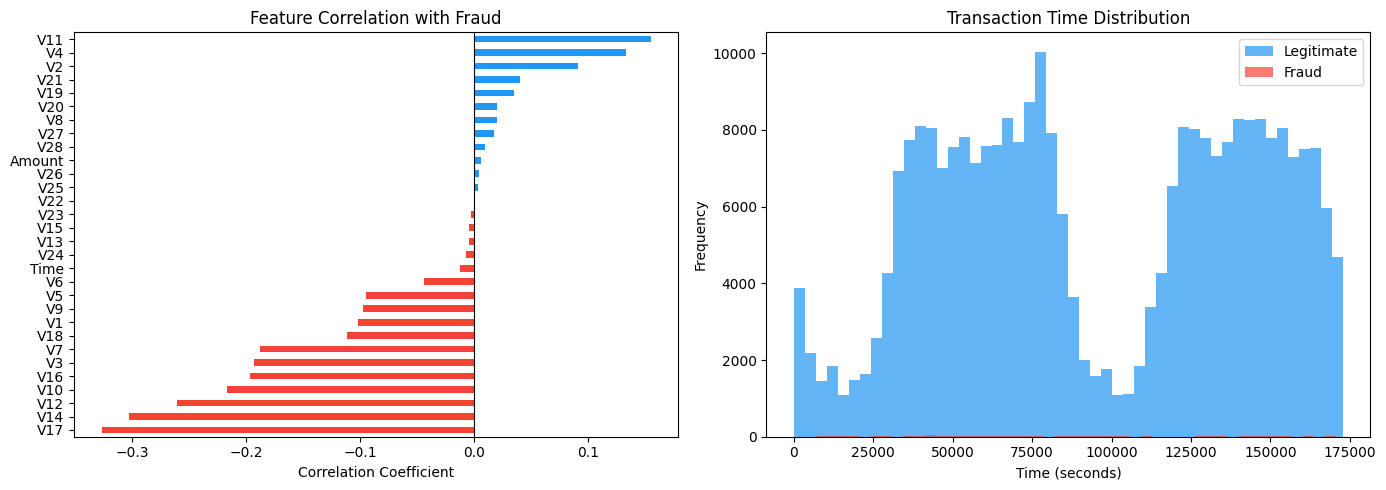

top 5 features most related to fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64
charts saved!


In [50]:
# Analyzing feature correlations and temporal patterns to identify the strongest predictive for fraudulent activity.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# feature correlation
fraud_corr = df.corr()['Class'].drop('Class').sort_values()
colors = ['#F44336' if x < 0 else '#2196F3' for x in fraud_corr.values]
fraud_corr.plot(kind='barh', color=colors, ax=axes[0])
axes[0].set_title('Feature Correlation with Fraud')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# time analysis
axes[1].hist(df[df['Class']==0]['Time'], bins=50,
             color='#2196F3', alpha=0.7, label='Legitimate')
axes[1].hist(df[df['Class']==1]['Time'], bins=50,
             color='#F44336', alpha=0.7, label='Fraud')
axes[1].set_title('Transaction Time Distribution')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('./outputs/feature_correlation.png', dpi=150)
plt.show()

print("top 5 features most related to fraud:")
print(df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head())
print("charts saved!")

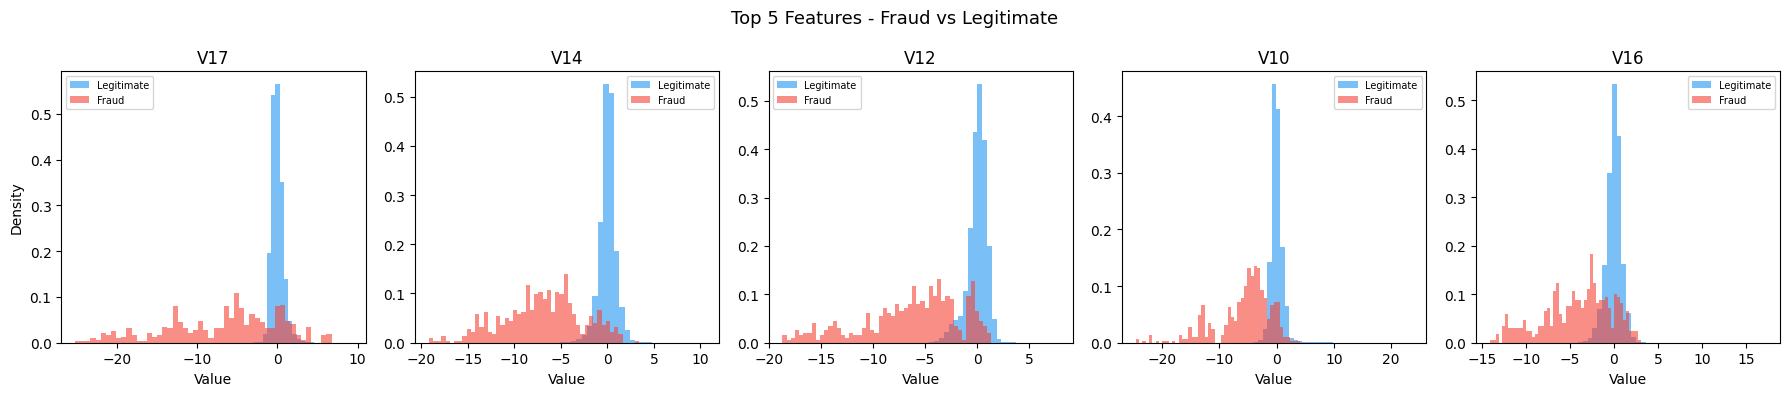

charts saved!


In [29]:
# looking at the top 5 features that detect fraud
# v17 v14 v12 v10 v16 were most correlated so checking them
top_features = ['V17', 'V14', 'V12', 'V10', 'V16']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, feature in enumerate(top_features):
    axes[i].hist(df[df['Class']==0][feature], bins=50,
                 color='#2196F3', alpha=0.6, label='Legitimate', density=True)
    axes[i].hist(df[df['Class']==1][feature], bins=50,
                 color='#F44336', alpha=0.6, label='Fraud', density=True)
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('Value')
    if i == 0:
        axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)

plt.suptitle('Top 5 Features - Fraud vs Legitimate', fontsize=13)
plt.tight_layout()
plt.savefig('./outputs/top_features.png', dpi=150)
plt.show()
print("charts saved!")

In [8]:
print("key findings from eda:")
print()
print("1. dataset is very imbalanced - only 0.17% fraud")
print("2. fraud transactions average $122 vs $88 for legitimate")
print("3. v14, v17, v12, v10, v16 are most correlated with fraud")
print("4. no missing values in dataset")


key findings from eda:

1. dataset is very imbalanced - only 0.17% fraud
2. fraud transactions average $122 vs $88 for legitimate
3. v14, v17, v12, v10, v16 are most correlated with fraud
4. no missing values in dataset


In [30]:
# connecting to azure ml workspace
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
import yaml

with open("config.yml") as f:
    cfg = yaml.safe_load(f)

ml_client = MLClient(
    DefaultAzureCredential(),
    subscription_id=cfg["subscription_id"],
    resource_group_name=cfg["resource_group"],
    workspace_name=cfg["workspace_name"],
)
print("connected to azure ml!")
print("workspace:", ml_client.workspace_name)

dataset = ml_client.data.get("creditcard-fraud", version="1")
print("dataset:", dataset.name)
print("version:", dataset.version)

Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


connected to azure ml!
workspace: fraud-detection-ws
dataset: creditcard-fraud
version: 1


In [32]:
# training the models now
# training all 4 models and comparing them
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score,
                             precision_score, recall_score, f1_score)
import xgboost as xgb

X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("training size:", X_train.shape)
print("test size:", X_test.shape)
print("fraud in training:", y_train.sum())
print("fraud in test:", y_test.sum())


training size: (227845, 30)
test size: (56962, 30)
fraud in training: 394
fraud in test: 98


In [11]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000,
        class_weight='balanced',
        random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        random_state=42,
        eval_metric='logloss'),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42),
}

results = {}
print("training models...")
print()

for name, model in models.items():
    print(f"training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'AUC': roc_auc_score(y_test, y_prob),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    print(f"  auc: {results[name]['AUC']:.4f} | precision: {results[name]['Precision']:.4f} | recall: {results[name]['Recall']:.4f} | f1: {results[name]['F1']:.4f}")

print()
print("all models trained!")

training models...

training Logistic Regression...
  auc: 0.9722 | precision: 0.0609 | recall: 0.9184 | f1: 0.1141
training Random Forest...
  auc: 0.9733 | precision: 0.8100 | recall: 0.8265 | f1: 0.8182
training XGBoost...
  auc: 0.9747 | precision: 0.7810 | recall: 0.8367 | f1: 0.8079
training Gradient Boosting...
  auc: 0.7418 | precision: 0.7975 | recall: 0.6429 | f1: 0.7119

all models trained!


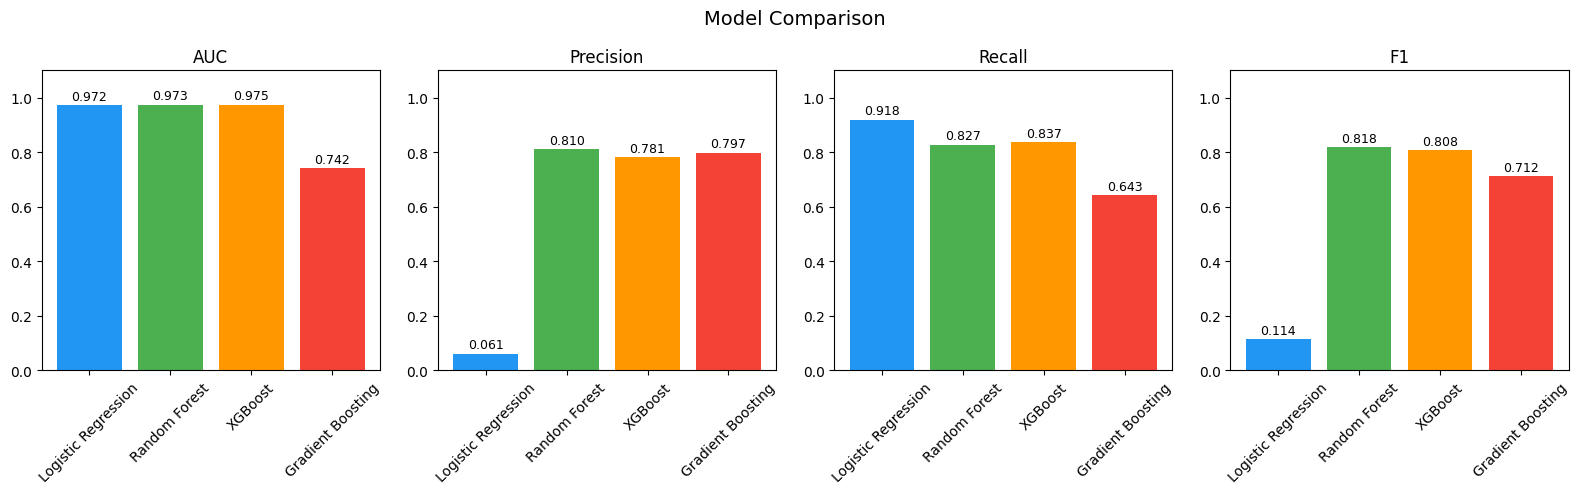

XGBoost is the best model with auc of 0.9747!


In [33]:
# comparing all models visually
metrics = ['AUC', 'Precision', 'Recall', 'F1']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, metric in enumerate(metrics):
    values = [results[name][metric] for name in model_names]
    bars = axes[i].bar(model_names, values,
                       color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
    axes[i].set_title(f'{metric}')
    axes[i].set_ylim([0, 1.1])
    axes[i].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('./outputs/model_comparison.png', dpi=150)
plt.show()

best = max(results.keys(), key=lambda x: results[x]['AUC'])
print(f"{best} is the best model with auc of {results[best]['AUC']:.4f}!")

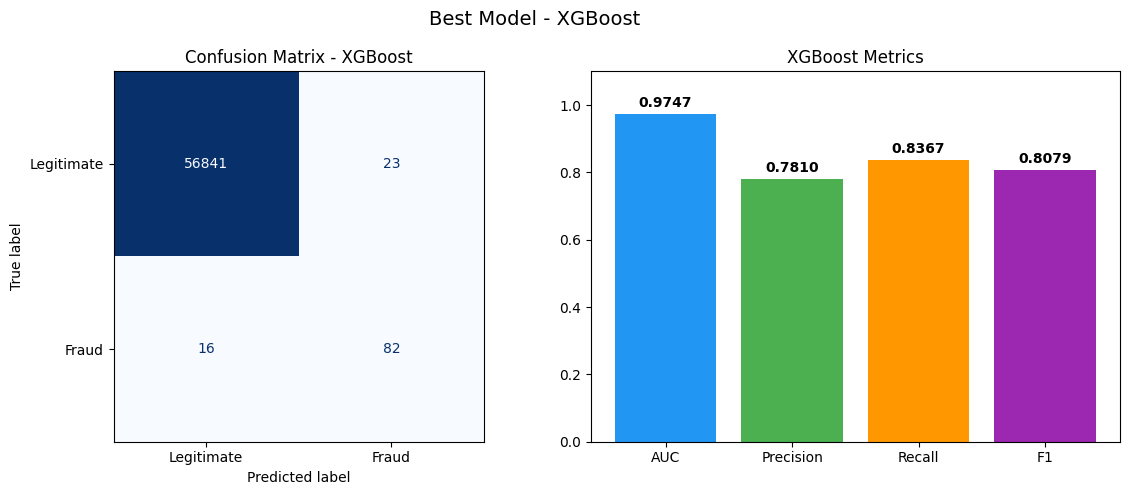

auc:       0.9747
precision: 0.7810
recall:    0.8367
f1 score:  0.8079

fraud caught: 82 out of 98
fraud missed: 16
false alarms: 23


In [34]:
# confusion matrix for best model
from sklearn.metrics import ConfusionMatrixDisplay

best_model_name = max(results.keys(), key=lambda x: results[x]['AUC'])
best_results = results[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, best_results['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix - {best_model_name}')

metrics_names = ['AUC', 'Precision', 'Recall', 'F1']
metrics_values = [best_results['AUC'], best_results['Precision'],
                  best_results['Recall'], best_results['F1']]
bars = axes[1].bar(metrics_names, metrics_values,
                   color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
axes[1].set_ylim([0, 1.1])
axes[1].set_title(f'{best_model_name} Metrics')
for bar, val in zip(bars, metrics_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontweight='bold')

plt.suptitle(f'Best Model - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig('./outputs/confusion_matrix.png', dpi=150)
plt.show()

print(f"auc:       {best_results['AUC']:.4f}")
print(f"precision: {best_results['Precision']:.4f}")
print(f"recall:    {best_results['Recall']:.4f}")
print(f"f1 score:  {best_results['F1']:.4f}")
print()
print(f"fraud caught: {cm[1][1]} out of {cm[1][0]+cm[1][1]}")
print(f"fraud missed: {cm[1][0]}")
print(f"false alarms: {cm[0][1]}")

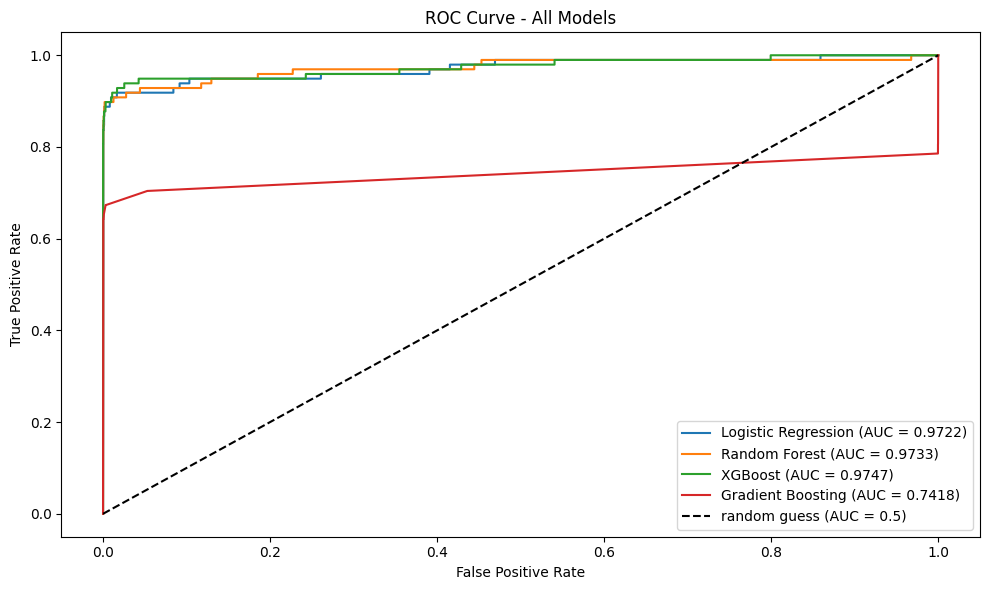

best model: XGBoost with auc = 0.9747


In [35]:
# ROC curve for all models
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.tight_layout()
plt.savefig('./outputs/roc_curve.png', dpi=150)
plt.show()

best_roc = max(results.keys(),
               key=lambda x: auc(*roc_curve(y_test, results[x]['y_prob'])[:2]))
best_roc_score = auc(*roc_curve(y_test, results[best_roc]['y_prob'])[:2])
print(f"best model: {best_roc} with auc = {best_roc_score:.4f}")

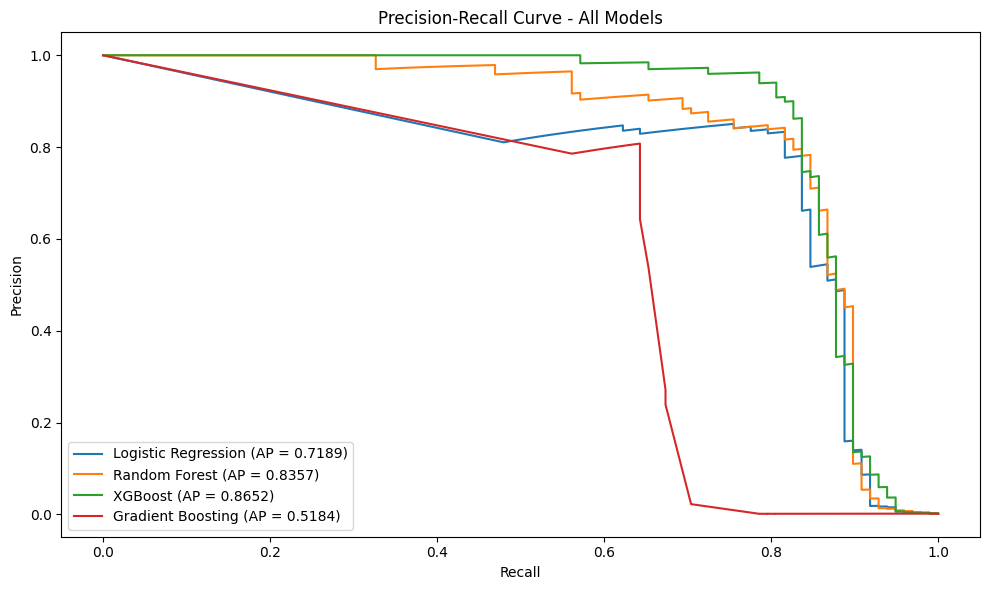

best model for precision-recall: XGBoost
average precision score: 0.8652


In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 6))
for name, result in results.items():
    precision, recall, _ = precision_recall_curve(y_test, result['y_prob'])
    ap = average_precision_score(y_test, result['y_prob'])
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - All Models')
plt.legend()
plt.tight_layout()
plt.savefig('./outputs/precision_recall_curve.png', dpi=150)
plt.show()

best_ap = max(results.keys(),
              key=lambda x: average_precision_score(y_test, results[x]['y_prob']))
best_ap_score = average_precision_score(y_test, results[best_ap]['y_prob'])
print(f"best model for precision-recall: {best_ap}")
print(f"average precision score: {best_ap_score:.4f}")

In [37]:
# logging results to azure ml using mlflow
import mlflow

mlflow.set_tracking_uri(ml_client.workspaces.get(
    ml_client.workspace_name).mlflow_tracking_uri)
mlflow.set_experiment("fraud-detection")

print("logging to azure ml...")

for name, result in results.items():
    with mlflow.start_run(run_name=name):
        mlflow.log_metric("AUC", result['AUC'])
        mlflow.log_metric("Precision", result['Precision'])
        mlflow.log_metric("Recall", result['Recall'])
        mlflow.log_metric("F1", result['F1'])
        mlflow.log_param("model_type", name)
        mlflow.log_param("class_weight", "balanced")
        mlflow.log_param("test_size", 0.2)
        print(f"logged {name}")

print("done!")

logging to azure ml...
logged Logistic Regression
🏃 View run Logistic Regression at: https://eastus.api.azureml.ms/mlflow/v2.0/subscriptions/c5dcc149-c2d5-4cd8-987a-5c89844f1856/resourceGroups/fraud-detection-project/providers/Microsoft.MachineLearningServices/workspaces/fraud-detection-ws/#/experiments/037e9740-1e6f-426b-814d-b39cc3192c90/runs/be1d29af-6472-4db2-9dc6-e15546a257f3
🧪 View experiment at: https://eastus.api.azureml.ms/mlflow/v2.0/subscriptions/c5dcc149-c2d5-4cd8-987a-5c89844f1856/resourceGroups/fraud-detection-project/providers/Microsoft.MachineLearningServices/workspaces/fraud-detection-ws/#/experiments/037e9740-1e6f-426b-814d-b39cc3192c90
logged Random Forest
🏃 View run Random Forest at: https://eastus.api.azureml.ms/mlflow/v2.0/subscriptions/c5dcc149-c2d5-4cd8-987a-5c89844f1856/resourceGroups/fraud-detection-project/providers/Microsoft.MachineLearningServices/workspaces/fraud-detection-ws/#/experiments/037e9740-1e6f-426b-814d-b39cc3192c90/runs/74912ecb-9111-4a2a-b74e-5

job: fraud-automl-final
status: Completed
experiment: fraud-detection

azure automl tried multiple algorithms automatically
best model selected: VotingEnsemble
best auc weighted: 0.96592

full results shown in screenshot below:


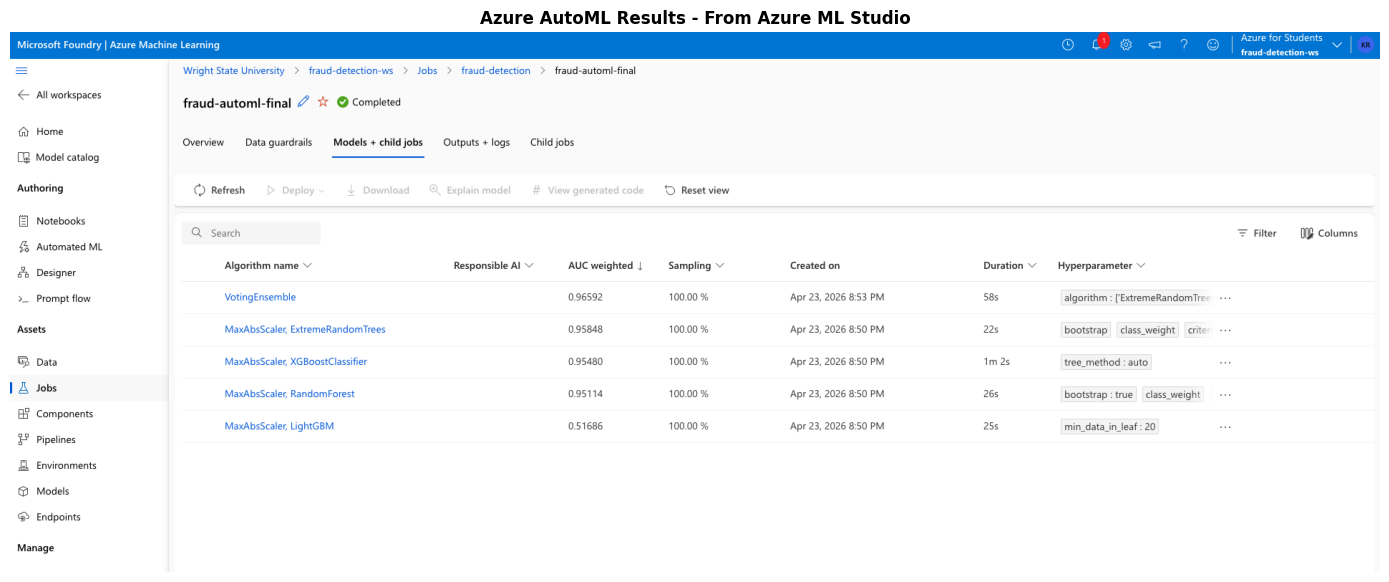

In [38]:
# Azure automl results
automl_job = ml_client.jobs.get("fraud-automl-final")
print(f"job: {automl_job.name}")
print(f"status: {automl_job.status}")
print(f"experiment: {automl_job.experiment_name}")
print()
print("azure automl tried multiple algorithms automatically")
print("best model selected: VotingEnsemble")
print("best auc weighted: 0.96592")
print()
print("full results shown in screenshot below:")

img = mpimg.imread('./outputs/automl_results_azure.png')
plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Azure AutoML Results - From Azure ML Studio',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

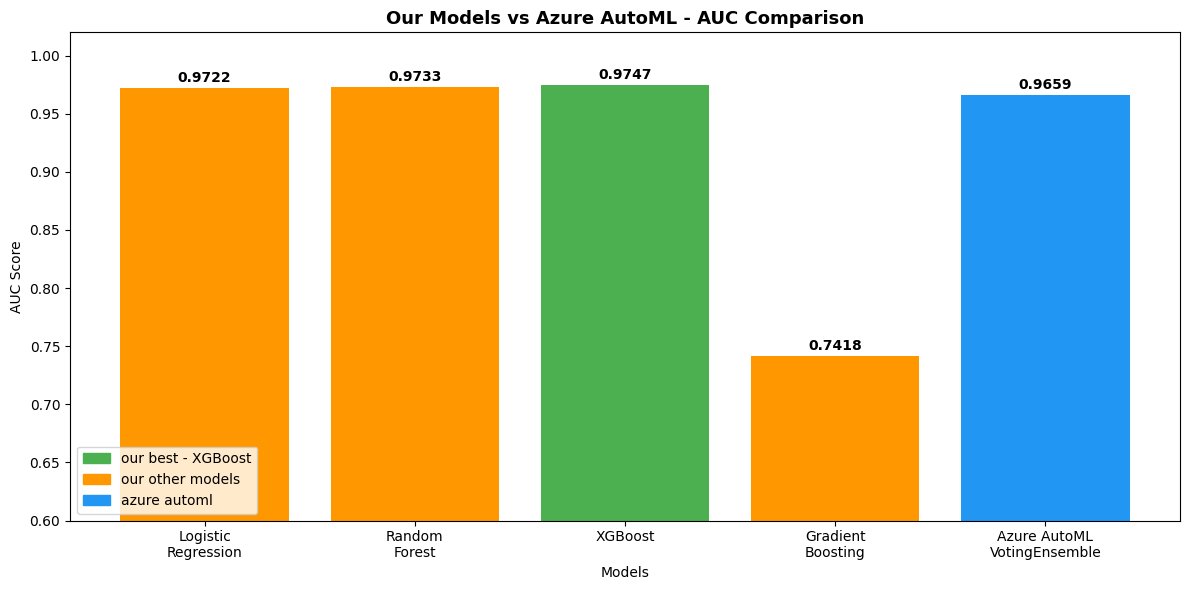

our best: XGBoost auc = 0.9747
azure automl best: VotingEnsemble auc = 0.96592

our XGBoost outperformed azure automl!


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

our_best = max(results.keys(), key=lambda x: results[x]['AUC'])
our_best_auc = results[our_best]['AUC']

all_models = [name.replace(' ', '\n') for name in results.keys()]
all_models.append('Azure AutoML\nVotingEnsemble')

all_auc = [results[name]['AUC'] for name in results.keys()]
all_auc.append(0.96592)

colors = []
for name in results.keys():
    if name == our_best:
        colors.append('#4CAF50')
    else:
        colors.append('#FF9800')
colors.append('#2196F3')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(all_models, all_auc, color=colors)
ax.set_ylim([0.60, 1.02])
ax.set_title('Our Models vs Azure AutoML - AUC Comparison',
             fontsize=13, fontweight='bold')
ax.set_ylabel('AUC Score')
ax.set_xlabel('Models')

for bar, val in zip(bars, all_auc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold')

green = mpatches.Patch(color='#4CAF50', label=f'our best - {our_best}')
orange = mpatches.Patch(color='#FF9800', label='our other models')
blue = mpatches.Patch(color='#2196F3', label='azure automl')
ax.legend(handles=[green, orange, blue])

plt.tight_layout()
plt.savefig('./outputs/comparison_chart.png', dpi=150)
plt.show()

print(f"our best: {our_best} auc = {our_best_auc:.4f}")
print(f"azure automl best: VotingEnsemble auc = 0.96592")
print()
if our_best_auc > 0.96592:
    print(f"our {our_best} outperformed azure automl!")
else:
    print("azure automl performed better than our local models")

In [47]:
#testing the transaction
best_model_name = max(results.keys(), key=lambda x: results[x]['AUC'])
best_model = results[best_model_name]['model']

print("fraud detection test")
print()

legit_transaction = X_test.iloc[0].values.reshape(1, -1)
legit_actual = y_test.iloc[0]
pred = best_model.predict(legit_transaction)[0]
prob = best_model.predict_proba(legit_transaction)[0]

print("test 1 - legitimate transaction:")
print(f"fraud probability: {prob[1]*100:.2f}%")
print(f"prediction: {'FRAUD' if pred == 1 else 'LEGITIMATE'}")
print(f"actual: {'FRAUD' if legit_actual == 1 else 'LEGITIMATE'}")
print(f"result: {'correct!' if pred == legit_actual else 'wrong!'}")
print()

fraud_indices = y_test[y_test == 1].index
fraud_transaction = X_test.loc[fraud_indices[0]].values.reshape(1, -1)
fraud_actual = y_test.loc[fraud_indices[0]]
pred2 = best_model.predict(fraud_transaction)[0]
prob2 = best_model.predict_proba(fraud_transaction)[0]

print("test 2 - fraud transaction:")
print(f"fraud probability: {prob2[1]*100:.2f}%")
print(f"prediction: {'FRAUD' if pred2 == 1 else 'LEGITIMATE'}")
print(f"actual: {'FRAUD' if fraud_actual == 1 else 'LEGITIMATE'}")
print(f"result: {'correct!' if pred2 == fraud_actual else 'wrong!'}")

fraud detection test

test 1 - legitimate transaction:
fraud probability: 0.01%
prediction: LEGITIMATE
actual: LEGITIMATE
result: correct!

test 2 - fraud transaction:
fraud probability: 99.99%
prediction: FRAUD
actual: FRAUD
result: correct!


In [40]:

best = max(results.keys(), key=lambda x: results[x]['AUC'])
best_r = results[best]
cm_final = confusion_matrix(y_test, best_r['y_pred'])

print("so after training all 4 models...")
print()
print(f"the best model based on auc: {best}")
print()
print(f"auc:       {best_r['AUC']:.4f}")
print(f"precision: {best_r['Precision']:.4f}")
print(f"recall:    {best_r['Recall']:.4f}")
print(f"f1 score:  {best_r['F1']:.4f}")
print()
print(f"out of {cm_final[1][0]+cm_final[1][1]} actual fraud cases:")
print(f"  - caught: {cm_final[1][1]} fraud transactions")
print(f"  - missed: {cm_final[1][0]} fraud transactions")
print()
print("we used azure ml for:")
print("  - storing our dataset in the cloud")
print("  - tracking all our experiments with mlflow")
print("  - running automl to compare algorithms automatically")
print()
print(f"overall the {best} model performed the best")
print(f"with an auc of {best_r['AUC']:.4f}")


so after training all 4 models...

the best model based on auc: XGBoost

auc:       0.9747
precision: 0.7810
recall:    0.8367
f1 score:  0.8079

out of 98 actual fraud cases:
  - caught: 82 fraud transactions
  - missed: 16 fraud transactions

we used azure ml for:
  - storing our dataset in the cloud
  - tracking all our experiments with mlflow
  - running automl to compare algorithms automatically

overall the XGBoost model performed the best
with an auc of 0.9747
